# EPG4001 Aprendizaje Supervisado
## Material Complementario — Clase 6
**Profesor:** Dr. Jorge Luis Bazán  
**Email:** jlbazan@uc.cl  
**Institución:** Pontificia Universidad Católica de Chile  

---

# 1. Carga de librerías

Las librerías a utilizar para los procedimientos en Python son las siguientes:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from IPython.display import display
except ImportError:
    display = print
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score
)

# Configuración de estilo gráfico
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (8, 5.5)

# 2. Ejemplo sección 1.1

Este ejemplo corresponde a un árbol de regresión con dos variables predictoras $x_1$ y $x_2$. La muestra a considerar es la siguiente:

In [ ]:
y  = [13, 3, 0, 6, 5, 6, 14, 6, 5, 3]
x1 = [9, 6, 1, 3, 3, 1, 9, 9, 4, 6]
x2 = [6, 2, 6, 9, 7, 9, 8, 2, 6, 4]

datos = pd.DataFrame({'y': y, 'x1': x1, 'x2': x2})
display(datos)

,y,x1,x2
0,13,9,6
1,3,6,2
2,0,1,6
3,6,3,9
4,5,3,7
5,6,1,9
6,14,9,8
7,6,9,2
8,5,4,6
9,3,6,4


Dividimos la muestra considerando los siguientes nodos $x_1 < 4$ y $x_1 \geq 4$:

In [ ]:
nodo1 = datos[datos['x1'] < 4]
nodo2 = datos[datos['x1'] >= 4]

print("Nodo 1 (x1 < 4):")
display(nodo1)
print("\nNodo 2 (x1 >= 4):")
display(nodo2)

Nodo 1 (x1 < 4):


,y,x1,x2
2,0,1,6
3,6,3,9
4,5,3,7
5,6,1,9



Nodo 2 (x1 >= 4):


,y,x1,x2
0,13,9,6
1,3,6,2
6,14,9,8
7,6,9,2
8,5,4,6
9,3,6,4


Calculamos las medias de cada región:

In [ ]:
media_n1 = nodo1['y'].mean()
media_n2 = nodo2['y'].mean()

print(f"Media y(x1 < 4) = {media_n1:.2f}")
print(f"Media y(x1 >= 4) = {media_n2:.2f}")

Media y(x1 < 4) = 4.25
Media y(x1 >= 4) = 7.33


Luego, realizamos la siguiente partición de la rama $x_1 \geq 4$ en función de la variable $x_2$, la que sería $x_2 < 5$ y $x_2 \geq 5$:

In [ ]:
nodo3 = datos[(datos['x1'] >= 4) & (datos['x2'] < 5)]
nodo4 = datos[(datos['x1'] >= 4) & (datos['x2'] >= 5)]

print("Nodo 3 (x1 >= 4 y x2 < 5):")
display(nodo3)
print("\nNodo 4 (x1 >= 4 y x2 >= 5):")
display(nodo4)

Nodo 3 (x1 >= 4 y x2 < 5):


,y,x1,x2
1,3,6,2
7,6,9,2
9,3,6,4



Nodo 4 (x1 >= 4 y x2 >= 5):


,y,x1,x2
0,13,9,6
6,14,9,8
8,5,4,6


Calculamos las medias:

In [ ]:
media_n3 = nodo3['y'].mean()
media_n4 = nodo4['y'].mean()

print(f"Media y(x1 >= 4 y x2 < 5) = {media_n3:.2f}")
print(f"Media y(x1 >= 4 y x2 >= 5) = {media_n4:.2f}")

Media y(x1 >= 4 y x2 < 5) = 4.00
Media y(x1 >= 4 y x2 >= 5) = 10.67


Luego las gráficas asociadas a este problema son las siguientes:

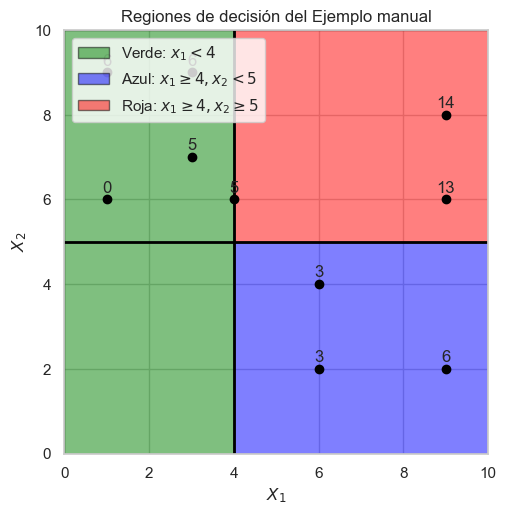

In [ ]:
fig, ax = plt.subplots()
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_xlabel('$X_1$')
ax.set_ylabel('$X_2$')
ax.set_aspect('equal')

# Región verde: x1 < 4
ax.add_patch(plt.Rectangle((0, 0), 4, 10, facecolor='green', edgecolor='black', alpha=0.5, label='Verde: $x_1 < 4$'))
# Región azul: x1 >= 4 y x2 < 5
ax.add_patch(plt.Rectangle((4, 0), 6, 5, facecolor='blue', edgecolor='black', alpha=0.5, label=r'Azul: $x_1 \geq 4, x_2 < 5$'))
# Región roja: x1 >= 4 y x2 >= 5
ax.add_patch(plt.Rectangle((4, 5), 6, 5, facecolor='red', edgecolor='black', alpha=0.5, label=r'Roja: $x_1 \geq 4, x_2 \geq 5$'))

ax.axvline(x=4, color='black', linewidth=2)
ax.axhline(y=5, color='black', linewidth=2)

ax.scatter(datos['x1'], datos['x2'], color='black', zorder=5)
for i, txt in enumerate(datos['y']):
    ax.annotate(txt, (datos['x1'].iloc[i], datos['x2'].iloc[i]), textcoords="offset points", xytext=(0,5), ha='center')

plt.legend(loc='upper left')
plt.title("Regiones de decisión del Ejemplo manual")
plt.show()

# 3. Gráfica funciones de funciones de pérdida sección 1.2.1

El objetivo es visualizar el comportamiento de las distintas funciones de pérdida para los árboles de clasificación. Primero definimos los rangos entre los que se moverá la función:

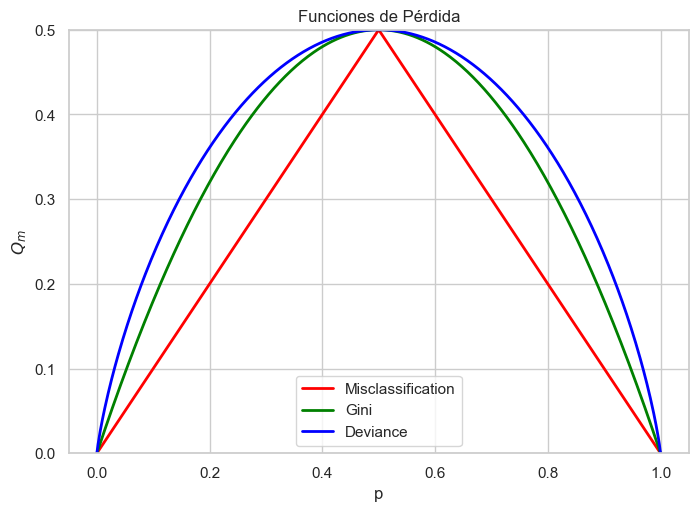

In [ ]:
# Valores del eje x (evitando 0 y 1 exactos por el logaritmo)
p = np.linspace(1e-5, 1 - 1e-5, 500)

Misclassification = 1 - np.maximum(p, 1 - p)
Gini = 2 * p * (1 - p)
Deviance = (-p * np.log(p) - (1 - p) * np.log(1 - p)) * (0.5 / np.log(2))

plt.figure()
plt.plot(p, Misclassification, color='red', linewidth=2, label='Misclassification')
plt.plot(p, Gini, color='green', linewidth=2, label='Gini')
plt.plot(p, Deviance, color='blue', linewidth=2, label='Deviance')

plt.ylim(0, 0.5)
plt.xlabel('p')
plt.ylabel('$Q_m$')
plt.title('Funciones de Pérdida')
plt.legend(loc='lower center')
plt.show()

# 4. Árbol de Clasificación

Utilizaremos la base de datos **PimaIndiansDiabetes**. Esta base contiene información
clínica de 768 pacientes y una variable de respuesta binaria que indica la presencia (pos) o ausencia
(neg) de diabetes.Primero cargamos la base de datos. En Python se puede descargar directamente mediante su URL pública del repositorio UCI para evitar dependencias externas:

In [ ]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columnas = ['pregnant', 'glucose', 'pressure', 'triceps', 'insulin', 'mass', 'pedigree', 'age', 'diabetes']
datos = pd.read_csv(url, names=columnas)

# Convertimos la respuesta en categórica string ('neg', 'pos') para mantener paridad con R
datos['diabetes'] = datos['diabetes'].map({0: 'neg', 1: 'pos'})
display(datos.head())

,pregnant,glucose,pressure,triceps,insulin,mass,pedigree,age,diabetes
0,6,148,72,35,0,33.6,0.627,50,pos
1,1,85,66,29,0,26.6,0.351,31,neg
2,8,183,64,0,0,23.3,0.672,32,pos
3,1,89,66,23,94,28.1,0.167,21,neg
4,0,137,40,35,168,43.1,2.288,33,pos


Separación en 80% entrenamiento y 20% prueba:

In [ ]:
X = datos.drop(columns=['diabetes'])
y = datos['diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=123, stratify=y)

print(f"Dimensiones entrenamiento: {X_train.shape}")
print(f"Dimensiones prueba: {X_test.shape}")

Dimensiones entrenamiento: (614, 8)
Dimensiones prueba: (154, 8)


## 4.1 Ajuste del árbol

Ahora, ajustamos el árbol de clasficación utilizando todas las variables clínicas como predictoras

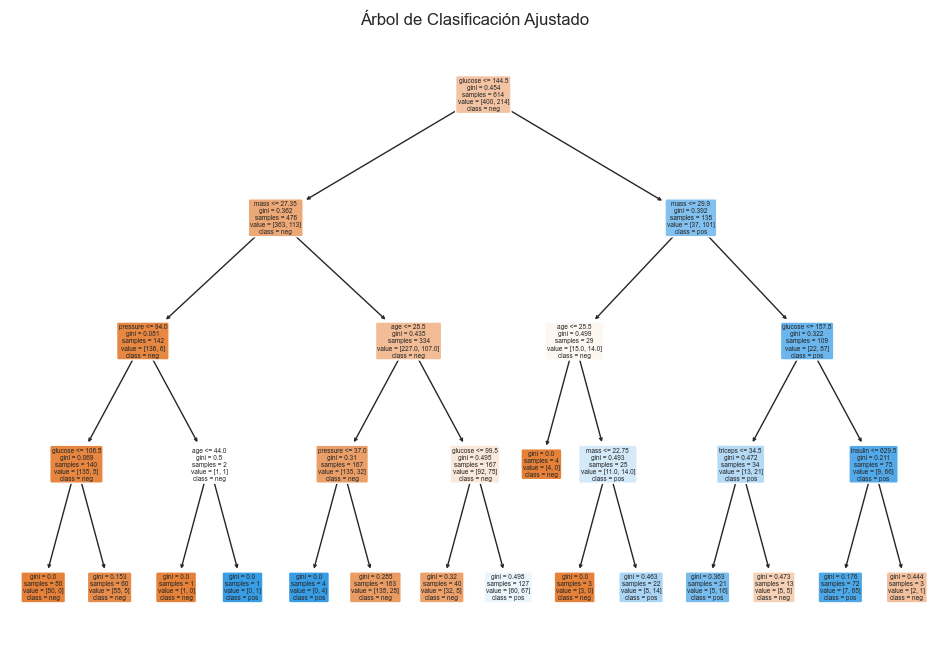

In [ ]:
tree_class = DecisionTreeClassifier(max_depth=4, random_state=123)  # Regulamos para visualización clara
tree_class.fit(X_train, y_train)

plt.figure(figsize=(12, 8))
plot_tree(tree_class, feature_names=X.columns, class_names=tree_class.classes_, filled=True, rounded=True)
plt.title("Árbol de Clasificación Ajustado")
plt.show()

Algunos comentarios son los siguiente:

- Es posible observar, que el nodo correspondiente a los individuos que cumplen la condición **glucose < 104** tiene la clase **neg** (no diabético) como clase predicha e indica que aproximadamente el **76 %** de las observaciones pertenecen a la categoría negativa, mientras que sólo el **24 %** corresponden a pacientes diabéticos. Además, este nodo contiene cerca del **77 %** de las observaciones de entrenamiento. Por lo tanto, pacientes con niveles relativamente bajos de glucosa presentan una baja probabilidad de padecer diabetes, lo que confirma la relevancia de esta variable para la clasificación.

- Por otro lado, en el nodo **glucose ≥ 144** y **mass ≥ 30**. La clase predicha es **pos** (diabético). Aproximadamente el **81 %** de los individuos pertenecen a la categoría positiva, mientras que sólo el **19 %** corresponde a pacientes sin diabetes. Este nodo agrupa cerca del **18 %** de las observaciones. Este resultado sugiere que pacientes con niveles elevados de glucosa y un índice de masa corporal alto presentan una alta probabilidad de padecer diabetes, lo que coincide con el conocimiento médico existente sobre los principales factores de riesgo asociados a esta enfermedad.

## 4.2 Predicción sobre el conjunto de prueba

Ahora, realizamos la predicción sobre el conjunto de test y visualizamos las métricas de desempeño respectivas

In [ ]:
pred_tree = tree_class.predict(X_test)

print("Matriz de Confusión:")
cm = confusion_matrix(y_test, pred_tree, labels=['neg', 'pos'])
cm_df = pd.DataFrame(cm, index=['Actual neg', 'Actual pos'], columns=['Pred neg', 'Pred pos'])
display(cm_df)

report = classification_report(y_test, pred_tree, output_dict=True)

acc_tree = accuracy_score(y_test, pred_tree)
sens_tree = report['pos']['recall']
spec_tree = report['neg']['recall']
prec_tree = report['pos']['precision']
f1_tree = report['pos']['f1-score']

metricas_tree = pd.DataFrame({
    'Métrica': ['Accuracy', 'Sensibilidad', 'Especificidad', 'Precisión', 'F1-score'],
    'Valor': [acc_tree, sens_tree, spec_tree, prec_tree, f1_tree]
})
display(metricas_tree.round(4))

Matriz de Confusión:


,Pred neg,Pred pos
Actual neg,73,27
Actual pos,12,42


,Métrica,Valor
0,Accuracy,0.7468
1,Sensibilidad,0.7778
2,Especificidad,0.7300
3,Precisión,0.6087
4,F1-score,0.6829


- El árbol de clasificación obtuvo una **exactitud (Accuracy)** de **0.7208**, lo que indica que aproximadamente el **72.08%** de las observaciones del conjunto de prueba fueron clasificadas correctamente.Este resultado sugiere un desempeño razonablemente bueno, considerando la complejidad inherente al
problema de detección de diabetes.

- La **sensibilidad (Sensitivity) fue de 0.6154**, indicando que el modelo identifica correctamente alrededor del **61.54%** de los pacientes que realmente presentan diabetes. En otras palabras, existe una proporción no despreciable de pacientes diabéticos que son clasificados erróneamente como no
diabéticos.

- Por otra parte, la **especificidad (Specificity) alcanzó un valor de 0.7745**, lo que significa que el modelo clasifica correctamente el **77.45%** de los pacientes que no presentan diabetes. Este resultado es superior a la sensibilidad, sugiriendo que el árbol tiene una mayor capacidad para identificar pacientes sanos que pacientes diabéticos.

- **La precisión (Precision) fue de 0.5818**, indicando que, entre todos los pacientes clasificados como diabéticos por el modelo, aproximadamente el **58.18%** efectivamente padecen la enfermedad. Esto evidencia la presencia de falsos positivos en las predicciones.

- Finalmente, el **F1-score fue de 0.5981**, valor que resume el equilibrio entre precisión y sensibilidad. Dado que este indicador es cercano a 0.60, se concluye que el modelo posee una capacidad modera da para detectar pacientes diabéticos, aunque existe margen de mejora en la identificación de casos
positivos.

En conjunto, los resultados muestran que el árbol de clasificación presenta un desempeño aceptable y logra una buena capacidad general de discriminar entre clases, que puede eventualmente ser mejorada.

# 5. Árbol de Regresión

Para ilustrar un problema de regresión se utiliza la variable *glucose* como respuesta numérica.

In [ ]:
X_reg_train = X_train.drop(columns=['glucose'])
y_reg_train = X_train['glucose']

X_reg_test = X_test.drop(columns=['glucose'])
y_reg_test = X_test['glucose']

tree_reg = DecisionTreeRegressor(max_depth=4, random_state=123)
tree_reg.fit(X_reg_train, y_reg_train)

DecisionTreeRegressor(max_depth=4, random_state=123)

Visualización del árbol de regresión:

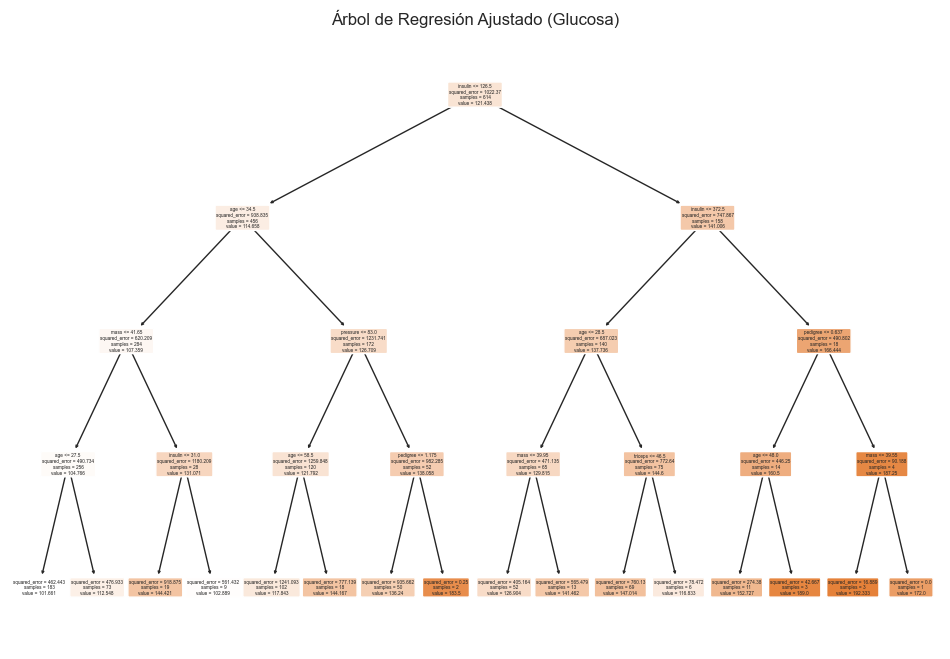

In [ ]:
plt.figure(figsize=(12, 8))
plot_tree(tree_reg, feature_names=X_reg_train.columns, filled=True, rounded=True)
plt.title("Árbol de Regresión Ajustado (Glucosa)")
plt.show()

Algunos comentarios son los siguientes:


- El nodo raíz divide a las observaciones según la variable **insulin**. En particular, los individuos con **insulin < 120** representan aproximadamente el **72 %** de las observaciones, mientras que aquellos con **insulin ≥ 120** corresponden al **28 %**. Esto sugiere que el nivel de insulina es la variable más importante para realizar la primera partición del conjunto de datos.

- En la rama izquierda (**insulin < 120**), la siguiente variable relevante es **pressure**. Cuando **pressure < 69**, el árbol continúa dividiendo según **triceps** y posteriormente por el índice de masa corporal (**mass**), identificando grupos con características similares. En cambio, cuando **pressure ≥ 69**, la clasificación depende nuevamente de la insulina y posteriormente de variables como **mass**, **pressure**, **triceps** y **pregnant**, lo que evidencia que el árbol utiliza distintas combinaciones de variables para caracterizar a los pacientes.

- En la rama derecha (**insulin ≥ 120**), el árbol vuelve a dividir según el nivel de insulina, utilizando el umbral **insulin < 262**. Para este grupo, la variable **pregnant** resulta determinante, separando a las pacientes con menos de tres embarazos de aquellas con tres o más. Esto indica que, entre individuos con niveles elevados de insulina, el número de embarazos aporta información adicional para la clasificación.

- En términos generales, el árbol muestra que las variables **insulin**, **pressure**, **mass**, **triceps** y **pregnant** son las principales responsables de segmentar la población. La repetición de la variable **insulin** en distintos niveles del árbol evidencia su alta capacidad discriminante, mientras que las demás variables refinan progresivamente la clasificación de los individuos.

## 5.2 Predicción sobre el conjunto de test

Se utiliza el mismo comando que en lasección anterior con la diferencia de que en este caso la respuesta es numérica,por ende las métricas de desempeño a considerar son distintas.

In [ ]:
pred_reg = tree_reg.predict(X_reg_test)

rmse = np.sqrt(mean_squared_error(y_reg_test, pred_reg))
mae = mean_absolute_error(y_reg_test, pred_reg)
r2 = r2_score(y_reg_test, pred_reg)

metricas_reg = pd.DataFrame({
    'Métrica': ['RMSE', 'MAE', 'R2'],
    'Valor': [rmse, mae, r2]
})
display(metricas_reg.round(4))

,Métrica,Valor
0,RMSE,30.1555
1,MAE,22.7211
2,R2,0.0990


**Interpretación de las métricas de desempeño:**

- El árbol de regresión obtuvo un **RMSE de 30.23**, lo que indica que, en promedio, las predicciones difieren de los valores reales de glucosa en aproximadamente **30 unidades**. Debido a que esta métrica penaliza con mayor intensidad los errores grandes, el resultado sugiere que existen algunas observaciones para las cuales el árbol presenta errores de predicción considerables.

- Por otra parte, el **Error Medio Absoluto (MAE)** fue de **23.47**, lo que significa que el error absoluto promedio de las predicciones es de aproximadamente **23.5 unidades de glucosa**. Como el MAE es menos sensible a valores extremos que el RMSE, la diferencia entre ambas métricas sugiere la presencia de algunos errores relativamente grandes en ciertas observaciones.

- El **coeficiente de determinación ($R^2$)** fue de **0.1793**, indicando que el modelo explica aproximadamente el **17.93 %** de la variabilidad observada en los niveles de glucosa. Este valor es relativamente bajo, por lo que la capacidad explicativa del árbol resulta limitada.

- En conjunto, los resultados muestran que el árbol de regresión logra capturar parte de la relación entre las variables clínicas y los niveles de glucosa, pero aún existe una proporción importante de variabilidad que no es explicada por el modelo. Esto sugiere que la estructura del árbol es relativamente simple para describir completamente el comportamiento de la variable respuesta o que existen otros factores relevantes no considerados en el análisis.

# 6. Random Forest

Volvemos al problema de clasificación usando la variable respuesta *diabetes*.

## 6.1 Ajuste del modelo e Importancia de Variables

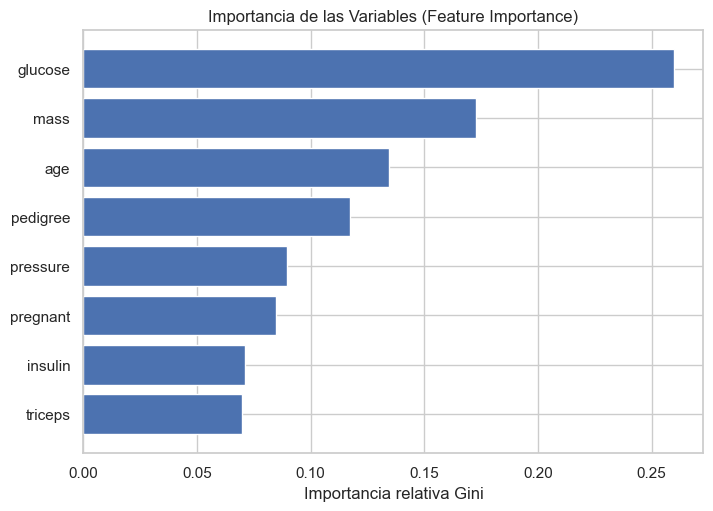

In [ ]:
rf = RandomForestClassifier(n_estimators=500, random_state=123)
rf.fit(X_train, y_train)

# Extracción de la importancia basada en la impureza de Gini
importancias = rf.feature_importances_
indices = np.argsort(importancias)

plt.figure()
plt.title("Importancia de las Variables (Feature Importance)")
plt.barh(range(X_train.shape[1]), importancias[indices], color='b', align='center')
plt.yticks(range(X_train.shape[1]), [X_train.columns[i] for i in indices])
plt.xlabel('Importancia relativa Gini')
plt.show()

**Interpretación de la importancia de las variables**

- La medida **Mean Decrease Accuracy** cuantifica cuánto disminuye la exactitud del modelo cuando se altera aleatoriamente una variable. Valores más altos indican que la variable es más importante para la capacidad predictiva del modelo. Por otra parte, **Mean Decrease Gini** mide la contribución de cada variable a la reducción de la impureza de los nodos a lo largo de todos los árboles del bosque.

- Se observa que la variable **glucose** es, por amplio margen, la más importante según ambas medidas. Esto indica que los niveles de glucosa constituyen el principal factor para distinguir entre pacientes diabéticos y no diabéticos. Este resultado es consistente con el conocimiento médico, ya que la glucosa sanguínea es uno de los indicadores más relevantes en el diagnóstico de diabetes.

- La segunda variable más importante es **mass** (índice de masa corporal), lo que sugiere que el sobrepeso y la obesidad tienen una influencia significativa en la presencia de la enfermedad. Posteriormente aparecen variables como **age** y **pedigree**, las cuales también aportan información relevante para la clasificación, aunque en menor medida.

- Por otro lado, variables como **pressure** y **triceps** presentan los menores niveles de importancia, indicando que su contribución al desempeño predictivo del modelo es relativamente reducida.

En términos generales, los resultados muestran que el modelo basa principalmente sus decisiones en variables relacionadas con factores metabólicos y antecedentes de riesgo, destacando especialmente la **glucose** y el **índice de masa corporal (mass)** como los predictores más influyentes para la detección de diabetes.

## 6.2 Predicciones sobre el conjunto de test

Realizamos la predicción en el conjunto de test y determinamos la matriz de confusión respectiva

In [ ]:
pred_rf = rf.predict(X_test)

report_rf = classification_report(y_test, pred_rf, output_dict=True)
acc_rf = accuracy_score(y_test, pred_rf)
sens_rf = report_rf['pos']['recall']
spec_rf = report_rf['neg']['recall']
prec_rf = report_rf['pos']['precision']
f1_rf = report_rf['pos']['f1-score']

metricas_rf = pd.DataFrame({
    'Métrica': ['Accuracy', 'Sensibilidad', 'Especificidad', 'Precisión', 'F1-score'],
    'Valor': [acc_rf, sens_rf, spec_rf, prec_rf, f1_rf]
})
display(metricas_rf.round(4))

,Métrica,Valor
0,Accuracy,0.7792
1,Sensibilidad,0.6111
2,Especificidad,0.8700
3,Precisión,0.7174
4,F1-score,0.6600


- El modelo **Random Forest obtuvo una Accuracy de 0.7922**, lo que indica que aproximadamente el **79.22%** de las observaciones del conjunto de prueba fueron clasificadas correctamente. Este resultado representa una mejora respecto al árbol de clasificación individual, sugiriendo que la combinación de
múltiples árboles permite obtener predicciones más robustas y precisas.

- La **sensibilidad fue de 0.6154**, indicando que el modelo identifica correctamente el **61.54%** de los pacientes que realmente presentan diabetes. Este valor coincide con el obtenido por el árbol de clasificación, por lo que la capacidad para detectar casos positivos no experimenta una mejora significativa.

- Por otra parte, la **especificidad alcanzó un valor de 0.8824**, lo que significa que el modelo clasifica correctamente el **88.24%** de los pacientes que no presentan diabetes. Este resultado es considerablemente superior al obtenido por el árbol individual, evidenciando una reducción importante de los falsos positivos.

- La **precisión fue de 0.7273**, indicando que aproximadamente el **72.73%** de los pacientes clasificados como diabéticos efectivamente padecen la enfermedad. Este valor es superior al observado en el árbol de clasificación, lo que refleja una mayor confiabilidad de las predicciones positivas.

- Finalmente, el **F1-score fue de 0.6667**, valor que resume el equilibrio entre precisión y sensibilidad. El incremento respecto al árbol individual indica que Random Forest logra un mejor compromiso entre la detección de pacientes diabéticos y la reducción de errores de clasificación.

En términos generales, los resultados muestran que Random Forest supera al árbol de clasificación en la mayoría de las métricas consideradas. La principal mejora se observa en la especificidad y en la precisión, lo que permite identificar con mayor exactitud a los pacientes sin diabetes y reducir la cantidad de diagnósticos positivos incorrectos.

## 6.3 Comparación entre Árbol y Random Forest

Los resultados para la predicción de glucose en términos de métricas para ambos métodos fueron los siguientes

In [ ]:
comparativa = pd.DataFrame({
    'Métrica': ['Accuracy', 'Sensibilidad', 'Especificidad', 'Precisión', 'F1-score'],
    'Árbol': [acc_tree, sens_tree, spec_tree, prec_tree, f1_tree],
    'Random Forest': [acc_rf, sens_rf, spec_rf, prec_rf, f1_rf]
})
display(comparativa.round(4))

,Métrica,Árbol,Random Forest
0,Accuracy,0.7468,0.7792
1,Sensibilidad,0.7778,0.6111
2,Especificidad,0.7300,0.8700
3,Precisión,0.6087,0.7174
4,F1-score,0.6829,0.6600


- Se observa que **Random Forest supera al árbol de clasificación en la mayoría de las métricas evaluadas**. En particular, la exactitud (Accuracy) aumenta de 0.7208 a 0.7922, lo que representa una mejora cercana a 7 puntos porcentuales en la proporción de observaciones clasificadas correctamente.
- La **sensibilidad se mantiene constante en ambos modelos (0.6154)**, indicando que la capacidad para identificar correctamente a los pacientes con diabetes no experimenta cambios significativos. Esto sugiere que ambos métodos detectan una proporción similar de casos positivos.
- La **especificidad aumenta considerablemente desde 0.7745 hasta 0.8824**. Esto implica que Random Forest logra identificar con mayor precisión a los pacientes que no presentan diabetes, reduciendo la cantidad de falsos positivos respecto al árbol individual.
- La **precisión mejora de 0.5818 a 0.7273**, indicando que las predicciones positivas realizadas por Random Forest son más confiables. En otras palabras, cuando el modelo clasifica a un paciente como diabético, la probabilidad de que dicha clasificación sea correcta es significativamente mayor.
- Finalmente, **el F1-score aumenta de 0.5981 a 0.6667**. Dado que esta métrica combina precisión y sensibilidad, el incremento observado refleja un mejor equilibrio entre la detección de pacientes diabéticos y la reducción de errores de clasificación.

En conjunto, los resultados muestran que Random Forest proporciona un desempeño superior al árbol de clasificación individual. La principal mejora se observa en la reducción de falsos positivos y en el aumento de la confiabilidad de las predicciones, mientras que la capacidad para detectar pacientes diabéticos se mantiene prácticamente constante.


# 7. Bibliografía

- James, G., Witten, D., Hastie, T., and Tibshirani, R. (2013) *An Introduction to Statistical Learning with applications in R*. Springer-Verlag, New York.
- Blake CL, Merz CJ (1998). "UCI Repository of Machine Learning Databases."